In [32]:
#data structures
import pandas as pd
import numpy as np

#data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#machine learning
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

#metrics (performance and machine learning scores)
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [4]:
#Loading the datasets
train_val = pd.read_csv('data/train_values.csv') #The data values of each building
train_labels = pd.read_csv('data/train_labels.csv') #labels of data as damage severity ('damage_grade')

df = pd.merge(train_val, train_labels, on='building_id')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   geo_level_1_id                          260601 non-null  int64 
 2   geo_level_2_id                          260601 non-null  int64 
 3   geo_level_3_id                          260601 non-null  int64 
 4   count_floors_pre_eq                     260601 non-null  int64 
 5   age                                     260601 non-null  int64 
 6   area_percentage                         260601 non-null  int64 
 7   height_percentage                       260601 non-null  int64 
 8   land_surface_condition                  260601 non-null  object
 9   foundation_type                         260601 non-null  object
 10  roof_type                               260601 non-null 

In [13]:
# prepare features and target
X = df.drop(columns=['building_id', 'damage_grade'])
y = df['damage_grade']

#Selecting categoricals and numerical variables
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

In [10]:
df['damage_grade'].value_counts()

damage_grade
2    148259
3     87218
1     25124
Name: count, dtype: int64

The three damage categories are unbalanced. I am doing the split (train/test) first, then doing sampling only on the training set.

In [16]:
# split first, preserving class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# undersample training set to match the smallest class (grade 1)
train = pd.concat([X_train, y_train], axis=1)
min_count = train['damage_grade'].value_counts().min()

train_balanced = (
    train
    .groupby('damage_grade', group_keys=False)
    .apply(lambda grp: grp.sample(n=min_count, random_state=42))
    .reset_index(drop=True)
)

X_train_bal = train_balanced.drop(columns=['damage_grade'])
y_train_bal = train_balanced['damage_grade']

C:\Users\silvz\AppData\Local\Temp\ipykernel_19820\890785565.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grp: grp.sample(n=min_count, random_state=42))


Build a preprocessing + PCA + classifier pipeline for the damage-grade task on the balanced dataset.

              precision    recall  f1-score   support

           1       0.39      0.79      0.52      5025
           2       0.74      0.51      0.60     29652
           3       0.56      0.69      0.62     17444

    accuracy                           0.60     52121
   macro avg       0.56      0.66      0.58     52121
weighted avg       0.65      0.60      0.60     52121

RF with PCA Validation F1: 0.5976094088755013


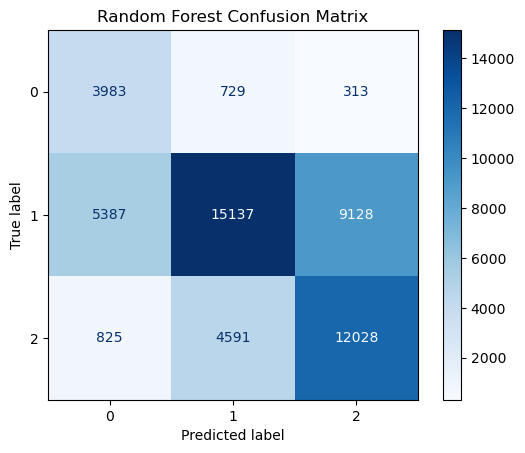

In [30]:
#Encoding categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols),
    ]
)

pipe = Pipeline([
    ('preproc', preprocessor),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        #max_features='sqrt',
        random_state=42,
        n_jobs=-1
        ))])

# Fitting on the balanced training set
pipe.fit(X_train_bal, y_train_bal)

y_pred = pipe.predict(X_test)
print(classification_report(y_test, y_pred))

rf_f1 = f1_score(y_test, y_pred, average='micro')
print("RF with PCA Validation F1:", rf_f1)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

Trying the RandomForestClassifier without PCA

              precision    recall  f1-score   support

           1       0.41      0.83      0.55      5025
           2       0.77      0.55      0.64     29652
           3       0.60      0.72      0.65     17444

    accuracy                           0.63     52121
   macro avg       0.59      0.70      0.61     52121
weighted avg       0.68      0.63      0.64     52121

RF without PCA Validation F1: 0.6312426852899983


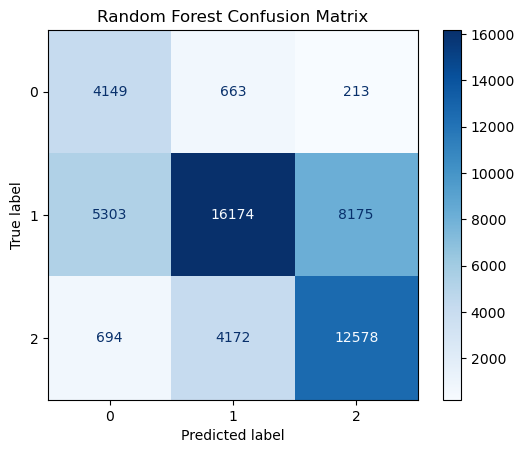

In [31]:
pipe = Pipeline([
    ('preproc', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        #max_features='sqrt',
        random_state=42,
        n_jobs=-1
        ))])

# Fitting on the balanced training set
pipe.fit(X_train_bal, y_train_bal)

y_pred = pipe.predict(X_test)
print(classification_report(y_test, y_pred))

rf_f1 = f1_score(y_test, y_pred, average='micro')
print("RF without PCA Validation F1:", rf_f1)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

For tree-based models, PCA is usually not necessary and can even hurt performance. This looks like the case here, where the F1 scores decreases from 0.63 to 0.6 when PCA is added to the pipeline. Also, the performance of the RF on a balanced dataset is "worse" than on the RF (see Virginia's RF analysis). Next, I have analyzed the effect of PCA on other two classifiers: mMltinomial Logistic Regression and KNeighborsClassifier

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression
              precision    recall  f1-score   support

           1       0.37      0.70      0.48      5025
           2       0.65      0.31      0.42     29652
           3       0.43      0.69      0.53     17444

    accuracy                           0.48     52121
   macro avg       0.48      0.57      0.48     52121
weighted avg       0.55      0.48      0.46     52121



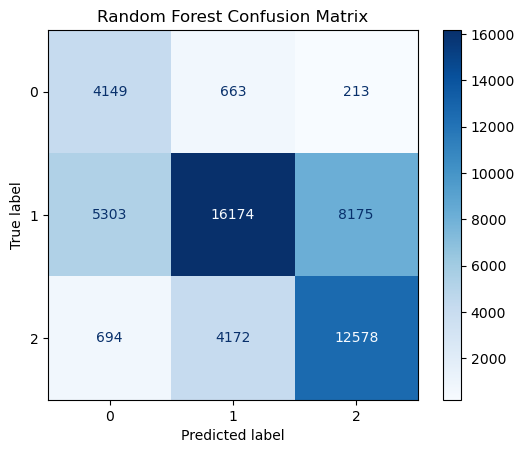

KNN
              precision    recall  f1-score   support

           1       0.31      0.81      0.45      5025
           2       0.70      0.47      0.56     29652
           3       0.54      0.60      0.57     17444

    accuracy                           0.54     52121
   macro avg       0.52      0.62      0.53     52121
weighted avg       0.61      0.54      0.55     52121



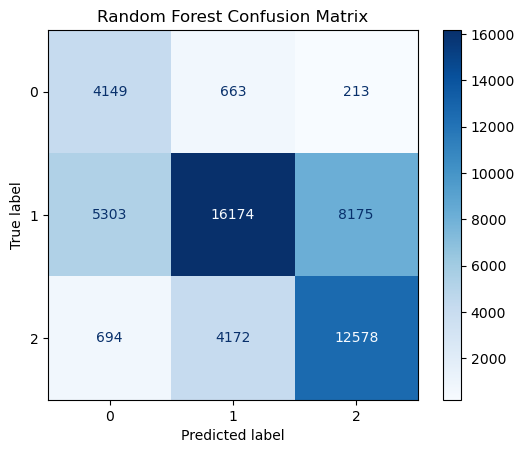

In [33]:
#Multinomial logistic regression
logistic_pipe = Pipeline([
    ('preproc', preprocessor),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('clf', LogisticRegression(
        multi_class='multinomial',
        solver='saga',
        max_iter=2000,
        random_state=42,
        n_jobs=-1
    ))
])

KNeighborsClassifier
knn_pipe = Pipeline([
    ('preproc', preprocessor),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('clf', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
])

# Fit on balanced training data
logistic_pipe.fit(X_train_bal, y_train_bal)
knn_pipe.fit(X_train_bal, y_train_bal)

# Evaluate
y_pred_log = logistic_pipe.predict(X_test)
y_pred_knn = knn_pipe.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, y_pred_log))

cm_log = confusion_matrix(y_test, y_pred_log)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

print("KNN")
print(classification_report(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression
              precision    recall  f1-score   support

           1       0.38      0.69      0.49      5025
           2       0.67      0.38      0.48     29652
           3       0.45      0.68      0.54     17444

    accuracy                           0.51     52121
   macro avg       0.50      0.58      0.50     52121
weighted avg       0.57      0.51      0.50     52121



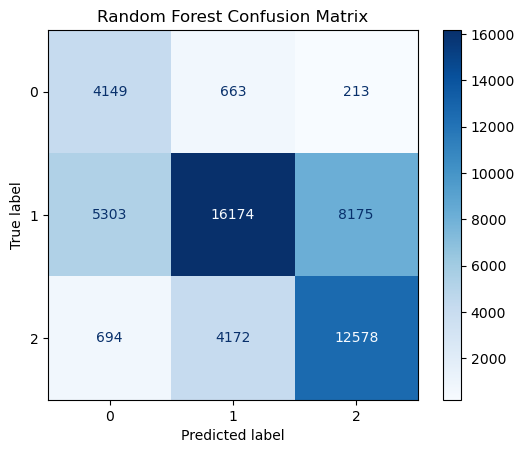

KNN
              precision    recall  f1-score   support

           1       0.31      0.80      0.45      5025
           2       0.70      0.47      0.56     29652
           3       0.54      0.60      0.57     17444

    accuracy                           0.54     52121
   macro avg       0.52      0.62      0.52     52121
weighted avg       0.61      0.54      0.55     52121



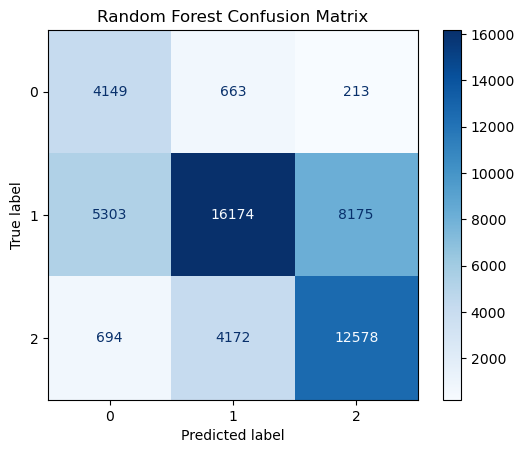

In [34]:
#Multinomial logistic regression without PCA
logistic_pipe = Pipeline([
    ('preproc', preprocessor),
    ('clf', LogisticRegression(
        multi_class='multinomial',
        solver='saga',
        max_iter=2000,
        random_state=42,
        n_jobs=-1
    ))
])

#KNeighborsClassifier without PCA
knn_pipe = Pipeline([
    ('preproc', preprocessor),
    ('clf', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
])

# Fit on balanced training data
logistic_pipe.fit(X_train_bal, y_train_bal)
knn_pipe.fit(X_train_bal, y_train_bal)

# Evaluate
y_pred_log_noPCA = logistic_pipe.predict(X_test)
y_pred_knn_noPCA = knn_pipe.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, y_pred_log_noPCA))

cm_log_noPCA = confusion_matrix(y_test, y_pred_log_noPCA)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

print("KNN")
print(classification_report(y_test, y_pred_knn_noPCA))

cm_knn = confusion_matrix(y_test, y_pred_knn_noPCA)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()


Also for these two models, PCA did not help boosting the performances